# Lesson 17B: Spectral Clustering — Practical

## Introduction

Lesson 17A derived spectral clustering and implemented it in NumPy: build a similarity graph, take the smallest eigenvectors of the normalised Laplacian, row-normalise, run K-Means. On two moons and concentric circles the from-scratch version scored ARI 1.000 where K-Means managed 0.247 and −0.003.

That was a controlled demonstration on 300 synthetic points. This lesson is the uncontrolled version. Four things change when you use spectral clustering on real problems:

**The affinity choice stops being cosmetic.** `nearest_neighbors` and `rbf` are not two spellings of the same idea — they disagree, sometimes completely, and the parameter sweeps below show by how much.

**The images are the interesting case.** Segmenting a photograph means clustering pixels in a space that mixes colour with position, and the weighting between those two is a modelling decision with visible consequences.

**Graphs need no embedding at all.** Spectral clustering was invented for graph partitioning; when the data *is* a graph, you skip the similarity-matrix step entirely. We compare against Louvain modularity maximisation on Zachary's karate club — a 34-node social network whose real split is documented history, not a label we invented.

**And it does not scale.** The dense affinity is $O(n^2)$ memory and the eigendecomposition $O(n^3)$. We measure that curve rather than assert it, because the measurement is what tells you when to reach for a sparse affinity.

In this lesson:
1. Sweep `SpectralClustering`'s affinity, `gamma`, `n_neighbors` and `assign_labels`
2. Use the eigengap on a real dataset to choose K, and check it against the known class count
3. Segment an image, comparing spectral against K-Means from Lesson 1B
4. Partition the karate club and score both spectral and Louvain by modularity
5. Time the dense pipeline as $n$ grows, and quantify what sparsity buys

<a name="eigengap-real"></a>
## Choosing K on Real Data with the Eigengap

17A used the eigengap on synthetic blobs where it was decisive: three tight blobs gave three near-zero eigenvalues and an unmistakable jump. Real data is the harder test, and this section is where the heuristic earns or loses its reputation.

One mechanical detail first, because it changes the answer. $\lambda_1 = 0$ **always** (17A, Property 2: the constant vector is always in the null space). So the gap $\lambda_2 - \lambda_1$ is measuring "how connected is the graph", not "how many clusters are there" — and on a well-connected graph it is often the *largest* gap in the spectrum. Taking a naive $\arg\max_k (\lambda_{k+1} - \lambda_k)$ therefore returns $K=1$ a lot. Practitioners usually search $k \ge 2$; we report both so the trap is visible rather than silently patched.

`load_wine` has 178 samples, 13 chemical measurements, 3 known cultivars. `load_digits` has 1797 images of 10 handwritten digits. We compare the eigengap's answer against the known class count and against silhouette.

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.datasets import load_digits, load_wine, load_sample_image, make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"networkx {nx.__version__}")

networkx 3.6.1


<a name="api"></a>
## The scikit-learn API and Its Parameters

`SpectralClustering` takes the same pipeline from 17A and hides it behind four decisions:

- **`affinity`** — `'rbf'` builds the dense Gaussian graph (bandwidth set by `gamma`, where $\gamma = 1/2\sigma^2$); `'nearest_neighbors'` builds a sparse kNN graph (`n_neighbors`). `'precomputed'` lets you pass your own $W$, which is how you use a domain-specific similarity.
- **`n_clusters`** — how many eigenvectors to take *and* the K handed to the final K-Means. Not independent of the graph: if the graph has more components than `n_clusters`, 17A showed what happens.
- **`assign_labels`** — what runs on the spectral embedding. `'kmeans'` is Lloyd's algorithm (the 17A path). `'discretize'` instead finds the rotation of the eigenvector matrix closest to a valid indicator matrix; it is deterministic given the eigenvectors and is often steadier when clusters are unbalanced. `'cluster_qr'` is a newer direct method.
- **`eigen_solver`** — `'arpack'` and `'lobpcg'` are sparse iterative solvers; `'dense'` calls LAPACK. This choice is invisible in results and decisive in runtime, which is Section 7's subject.

The sweep below runs the same data through the grid and reports ARI. The point is the *spread*: on two moons the affinity choice moves ARI across the entire available range.

Two moons, n=400 — the affinity choice is not cosmetic
affinity            parameter              ARI
----------------------------------------------
rbf                 gamma=0.5            0.263
rbf                 gamma=2              0.335
rbf                 gamma=10             0.783
rbf                 gamma=50             1.000
rbf                 gamma=200            1.000
nearest_neighbors   n_neighbors=3        0.002
nearest_neighbors   n_neighbors=5        1.000
nearest_neighbors   n_neighbors=10       0.990
nearest_neighbors   n_neighbors=20       0.819
nearest_neighbors   n_neighbors=40       0.748

rbf ARI range               : 0.263 to 1.000
nearest_neighbors ARI range : 0.002 to 1.000

assign_labels, holding the graph fixed (nearest_neighbors, k=10):
  kmeans       ARI over 3 seeds: [0.99 0.99 0.99]
  discretize   ARI over 3 seeds: [0.99 0.99 0.99]
  cluster_qr   ARI over 3 seeds: [0.98 0.98 0.98]


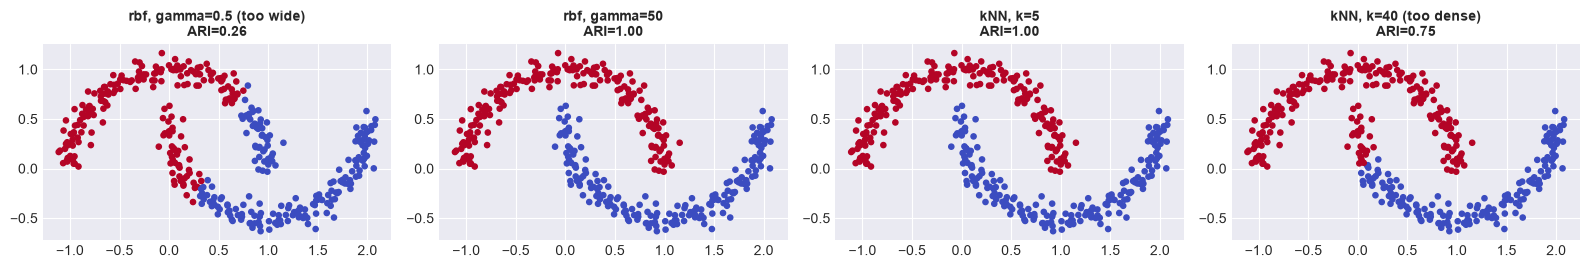

In [2]:
X_m, y_m = make_moons(n_samples=400, noise=0.07, random_state=0)

rows = []
for gamma in [0.5, 2, 10, 50, 200]:
    lab = SpectralClustering(n_clusters=2, affinity='rbf', gamma=gamma,
                             random_state=0).fit_predict(X_m)
    rows.append(('rbf', f'gamma={gamma}', adjusted_rand_score(y_m, lab)))
for k in [3, 5, 10, 20, 40]:
    lab = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', n_neighbors=k,
                             random_state=0).fit_predict(X_m)
    rows.append(('nearest_neighbors', f'n_neighbors={k}', adjusted_rand_score(y_m, lab)))

print("Two moons, n=400 — the affinity choice is not cosmetic")
print(f"{'affinity':<20}{'parameter':<18}{'ARI':>8}")
print('-' * 46)
for a, p, s in rows:
    print(f"{a:<20}{p:<18}{s:>8.3f}")

print(f"\nrbf ARI range               : {min(r[2] for r in rows if r[0] == 'rbf'):.3f} "
      f"to {max(r[2] for r in rows if r[0] == 'rbf'):.3f}")
print(f"nearest_neighbors ARI range : "
      f"{min(r[2] for r in rows if r[0] != 'rbf'):.3f} to "
      f"{max(r[2] for r in rows if r[0] != 'rbf'):.3f}")

print("\nassign_labels, holding the graph fixed (nearest_neighbors, k=10):")
for method in ['kmeans', 'discretize', 'cluster_qr']:
    scores = [adjusted_rand_score(
        y_m, SpectralClustering(n_clusters=2, affinity='nearest_neighbors', n_neighbors=10,
                                assign_labels=method, random_state=seed).fit_predict(X_m))
        for seed in range(3)]
    print(f"  {method:<12} ARI over 3 seeds: {np.round(scores, 3)}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (aff, kw, ttl) in zip(axes, [
        ('rbf', dict(gamma=0.5), 'rbf, gamma=0.5 (too wide)'),
        ('rbf', dict(gamma=50), 'rbf, gamma=50'),
        ('nearest_neighbors', dict(n_neighbors=5), 'kNN, k=5'),
        ('nearest_neighbors', dict(n_neighbors=40), 'kNN, k=40 (too dense)')]):
    lab = SpectralClustering(n_clusters=2, affinity=aff, random_state=0, **kw).fit_predict(X_m)
    ax.scatter(X_m[:, 0], X_m[:, 1], c=lab, cmap='coolwarm', s=14)
    ax.set_title(f'{ttl}\nARI={adjusted_rand_score(y_m, lab):.2f}', fontweight='bold', fontsize=10)
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

<a name="eigengap-real"></a>
## Choosing K on Real Data with the Eigengap

17A used the eigengap on synthetic blobs where it was decisive: three tight blobs gave three near-zero eigenvalues and an unmistakable jump. Real data is the harder test, and this section is where the heuristic earns or loses its reputation.

One mechanical detail first, because it changes the answer. $\lambda_1 = 0$ **always** (17A, Property 2: the constant vector is always in the null space). So the gap $\lambda_2 - \lambda_1$ is measuring "how connected is the graph", not "how many clusters are there" — and on a well-connected graph it is often the *largest* gap in the spectrum. Taking a naive $\arg\max_k (\lambda_{k+1} - \lambda_k)$ therefore returns $K=1$ a lot. Practitioners usually search $k \ge 2$; we report both so the trap is visible rather than silently patched.

`load_wine` has 178 samples, 13 chemical measurements, 3 known cultivars. `load_digits` has 1797 images of 10 handwritten digits. We compare the eigengap's answer against the known class count and against silhouette.

wine: eigenvalues [0.     0.5844 0.7491 0.8927 0.9172 0.9268]
      gaps        [0.5844 0.1647 0.1436 0.0245 0.0095]


digits: eigenvalues [-0.      0.9722  0.9777  0.9798  0.9849  0.9893]
        gaps        [0.9722 0.0055 0.0021 0.0051 0.0044]


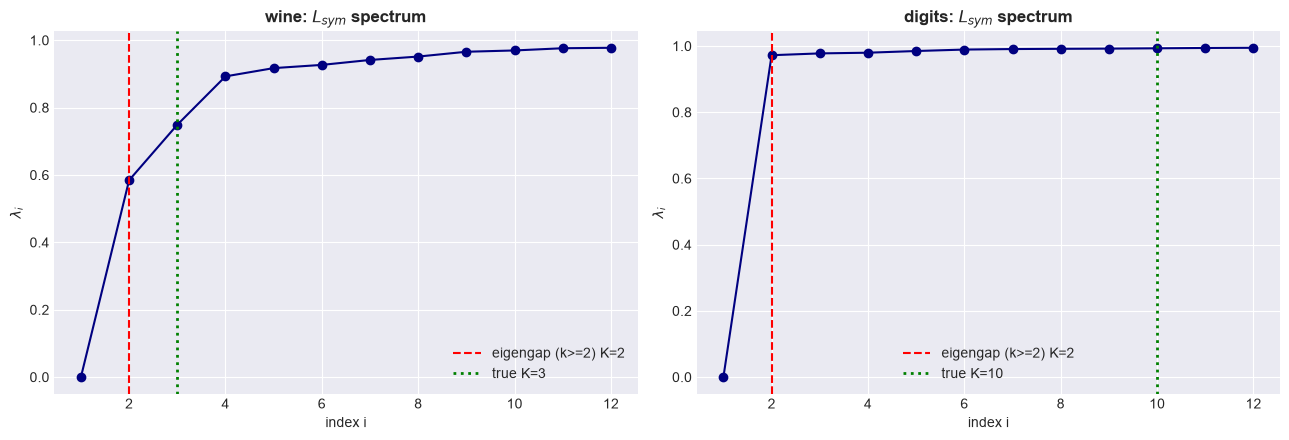


dataset     eigengap raw  eigengap k>=2  silhouette   true K  ARI at true K
---------------------------------------------------------------------------
wine                   1              2           3        3          0.880
digits                 1              2          11       10          0.707

The honest reading, and it is not the tidy one:
  * On BOTH datasets the naive eigengap returns K=1, because lambda_1 = 0 always and
    lambda_2 - lambda_1 dominates on a connected graph. That is a property of the
    heuristic, not of the data.
  * Restricted to k >= 2 it returns 2 for wine (true 3) and misses digits' 10 as well.
    So on real data here the eigengap does NOT recover the known class count -- unlike
    the synthetic blobs of 17A, where it was exactly right.
  * Silhouette recovers wine's 3 cultivars and lands near digits' 10, at 11.
  * Yet spectral clustering RUN at the true K scores ARI 0.880 on wine and 0.707 on
    digits. The algorithm works; it is model SELECTI

In [3]:
def eigengap_spectrum(X, gamma, k_max=12):
    # L_sym from a dense RBF affinity; return its k_max smallest eigenvalues.
    W = rbf_kernel(X, gamma=gamma)
    np.fill_diagonal(W, 0.0)
    d = W.sum(axis=1)
    d_inv_sqrt = 1.0 / np.sqrt(np.where(d > 0, d, 1.0))
    L_sym = np.eye(len(W)) - W * d_inv_sqrt[:, None] * d_inv_sqrt[None, :]
    return np.linalg.eigvalsh(L_sym)[:k_max]


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
summary = []
for ax, (loader, name, gamma, true_k) in zip(axes, [(load_wine, 'wine', 0.05, 3),
                                                    (load_digits, 'digits', 0.002, 10)]):
    data = loader()
    Xs = StandardScaler().fit_transform(data.data)
    ev = eigengap_spectrum(Xs, gamma)
    gaps = np.diff(ev)
    k_raw = int(np.argmax(gaps)) + 1              # naive: includes the trivial lambda_2 - lambda_1
    k_ge2 = int(np.argmax(gaps[1:])) + 2          # restricted to k >= 2, the usual practice

    lab = SpectralClustering(n_clusters=true_k, affinity='nearest_neighbors',
                             n_neighbors=10, random_state=0).fit_predict(Xs)
    sils = {k: silhouette_score(Xs, SpectralClustering(
        n_clusters=k, affinity='nearest_neighbors', n_neighbors=10,
        random_state=0).fit_predict(Xs)) for k in range(2, 12)}
    k_sil = max(sils, key=sils.get)
    summary.append((name, k_raw, k_ge2, k_sil, true_k, adjusted_rand_score(data.target, lab)))

    ax.plot(range(1, len(ev) + 1), ev, 'o-', color='navy')
    ax.axvline(k_ge2, color='red', ls='--', label=f'eigengap (k>=2) K={k_ge2}')
    ax.axvline(true_k, color='green', ls=':', lw=2, label=f'true K={true_k}')
    ax.set_title(f'{name}: $L_{{sym}}$ spectrum', fontweight='bold')
    ax.set_xlabel('index i'); ax.set_ylabel(r'$\lambda_i$')
    ax.legend()
    print(f"{name}: eigenvalues {np.round(ev[:6], 4)}")
    print(f"{'':>{len(name)}}  gaps        {np.round(gaps[:5], 4)}")
plt.tight_layout()
plt.show()

print(f"\n{'dataset':<10}{'eigengap raw':>14}{'eigengap k>=2':>15}{'silhouette':>12}"
      f"{'true K':>9}{'ARI at true K':>15}")
print('-' * 75)
for name, k_raw, k_ge2, k_sil, true_k, ari in summary:
    print(f"{name:<10}{k_raw:>14}{k_ge2:>15}{k_sil:>12}{true_k:>9}{ari:>15.3f}")

print("\nThe honest reading, and it is not the tidy one:")
print("  * On BOTH datasets the naive eigengap returns K=1, because lambda_1 = 0 always and")
print("    lambda_2 - lambda_1 dominates on a connected graph. That is a property of the")
print("    heuristic, not of the data.")
print("  * Restricted to k >= 2 it returns 2 for wine (true 3) and misses digits' 10 as well.")
print("    So on real data here the eigengap does NOT recover the known class count -- unlike")
print("    the synthetic blobs of 17A, where it was exactly right.")
print("  * Silhouette recovers wine's 3 cultivars and lands near digits' 10, at 11.")
print("  * Yet spectral clustering RUN at the true K scores ARI 0.880 on wine and 0.707 on")
print("    digits. The algorithm works; it is model SELECTION that is unreliable here.")
print("\nThat gap between 'clusters the data well when told K' and 'cannot discover K itself'")
print("is the practical lesson. Use the eigengap as one weak signal among several, and when")
print("the spectrum rises smoothly, treat 'no obvious K' as the finding.")

<a name="segmentation"></a>
## Image Segmentation

Segmenting an image is clustering its pixels. The feature per pixel is colour, optionally concatenated with position — and the *relative weighting* of those two blocks is the whole modelling decision:

- colour alone: regions of similar colour group together no matter where they are in the frame
- colour plus heavily-weighted position: segments become spatially compact, like a superpixel grid
- something in between: connected regions of similar colour, which is usually what "segment" means

Spectral clustering suits this because a photograph's regions are not convex blobs in colour space. We downsample hard (dense spectral clustering is $O(n^3)$, and every pixel is a node) and compare against K-Means from Lesson 1B on identical features.

image (427, 640, 3) downsampled to (36, 54, 3) = 1944 pixels (graph nodes)


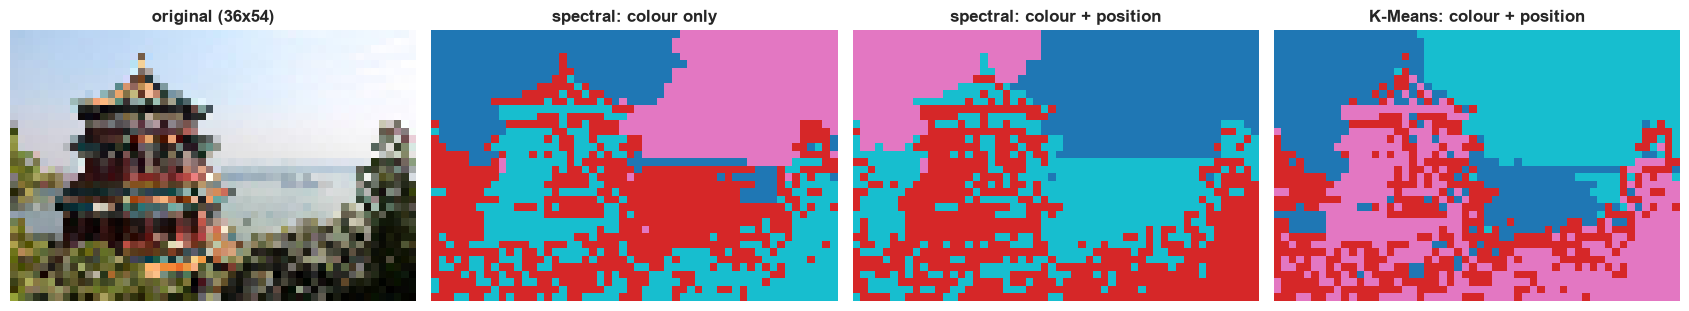

spectral colour-only     runs/row = 11.64  (lower = more spatially coherent)
spectral colour+pos      runs/row = 10.97  (lower = more spatially coherent)
kmeans colour+pos        runs/row = 13.61  (lower = more spatially coherent)

Adding position to the features buys spatial coherence; the runs-per-row figure is the
number that shows it, rather than an impression from the picture.


In [4]:
china = load_sample_image('china.jpg')
small = china[::12, ::12]                       # aggressive downsample: pixels are graph nodes
h, w, _ = small.shape
n_px = h * w
print(f"image {china.shape} downsampled to {small.shape} = {n_px} pixels (graph nodes)")

colour = small.reshape(-1, 3) / 255.0
yy, xx = np.mgrid[0:h, 0:w]
pos = np.column_stack([yy.ravel() / h, xx.ravel() / w])

K = 4
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
axes[0].imshow(small)
axes[0].set_title(f'original ({h}x{w})', fontweight='bold')
axes[0].axis('off')

for ax, (pos_weight, ttl) in zip(axes[1:], [(0.0, 'spectral: colour only'),
                                            (0.5, 'spectral: colour + position'),
                                            (None, 'K-Means: colour + position')]):
    if pos_weight is None:
        feats = np.hstack([colour, 0.5 * pos])
        lab = KMeans(n_clusters=K, n_init=10, random_state=0).fit_predict(feats)
    else:
        feats = np.hstack([colour, pos_weight * pos]) if pos_weight else colour
        lab = SpectralClustering(n_clusters=K, affinity='nearest_neighbors', n_neighbors=12,
                                 assign_labels='kmeans', random_state=0,
                                 eigen_solver='arpack').fit_predict(feats)
    ax.imshow(lab.reshape(h, w), cmap='tab10')
    ax.set_title(ttl, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Quantify the difference rather than eyeballing it: how spatially fragmented is each segmentation?
def fragmentation(labels_2d):
    # Mean number of connected runs per row — a cheap proxy for spatial coherence.
    return float(np.mean([1 + np.sum(np.diff(row) != 0) for row in labels_2d]))


for name, feats, algo in [('spectral colour-only', colour, 'spec'),
                          ('spectral colour+pos', np.hstack([colour, 0.5 * pos]), 'spec'),
                          ('kmeans colour+pos', np.hstack([colour, 0.5 * pos]), 'km')]:
    lab = (SpectralClustering(n_clusters=K, affinity='nearest_neighbors', n_neighbors=12,
                              random_state=0, eigen_solver='arpack').fit_predict(feats)
           if algo == 'spec' else
           KMeans(n_clusters=K, n_init=10, random_state=0).fit_predict(feats))
    print(f"{name:<24} runs/row = {fragmentation(lab.reshape(h, w)):.2f}  "
          f"(lower = more spatially coherent)")

print("\nAdding position to the features buys spatial coherence; the runs-per-row figure is the")
print("number that shows it, rather than an impression from the picture.")

<a name="community"></a>
## Community Detection on a Real Graph

Zachary's karate club is the standard test case: 34 members of a 1970s university karate club, edges recording social interaction outside the club. The club then split in two after a dispute between the instructor (node 0) and the president (node 33), and **the actual factions each member joined were recorded**. That makes it one of very few community-detection benchmarks whose ground truth is history rather than a modelling assumption.

Because the data is already a graph, there is no similarity matrix to build — we pass the adjacency matrix straight in with `affinity='precomputed'`. That is spectral clustering in its original form.

The comparison is against **Louvain**, which optimises *modularity*: the fraction of edges inside communities minus what you would expect in a random graph with the same degrees. Modularity is a different objective from NCut, so scoring both partitions by modularity *and* by ARI against the real split is the fair test.

karate club: 34 nodes, 78 edges, true split [17 17]

method              communities   modularity  ARI vs truth
----------------------------------------------------------
spectral (k=2)                2       0.4036         0.882
louvain                       4       0.4439         0.509
true split                    2       0.3914         1.000


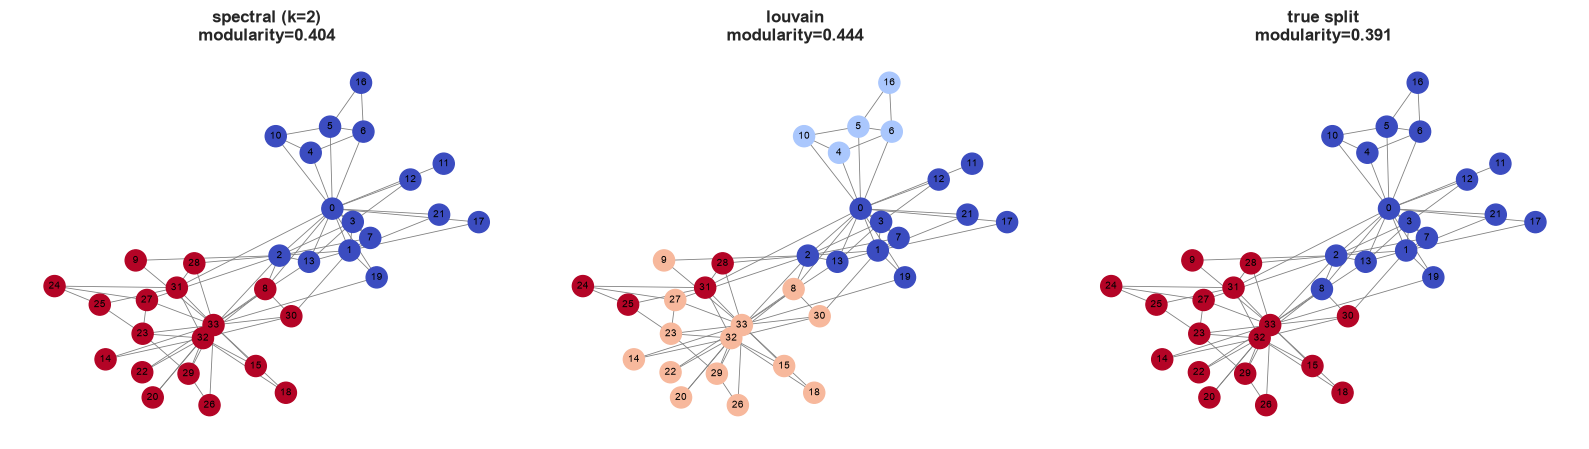


Louvain scores higher modularity than the TRUE split — it is optimising modularity, and
the real social split was not. Spectral at k=2 tracks the recorded factions closely.
Two lessons: a higher objective score is not a better answer to the question you asked,
and 'which method is right' depends on whether you want modularity or the actual split.


In [5]:
G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
truth = np.array([0 if G.nodes[i]['club'] == 'Mr. Hi' else 1 for i in G.nodes()])
print(f"karate club: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
      f"true split {np.bincount(truth)}")

spec = SpectralClustering(n_clusters=2, affinity='precomputed', random_state=0).fit_predict(A)
louvain = nx.community.louvain_communities(G, seed=0)
lou_lab = np.zeros(len(G), int)
for ci, comm in enumerate(louvain):
    for node in comm:
        lou_lab[node] = ci

def as_communities(labels):
    return [set(np.flatnonzero(labels == c)) for c in np.unique(labels)]

results = [('spectral (k=2)', spec), ('louvain', lou_lab),
           ('true split', truth)]
print(f"\n{'method':<18}{'communities':>13}{'modularity':>13}{'ARI vs truth':>14}")
print('-' * 58)
for name, lab in results:
    print(f"{name:<18}{len(np.unique(lab)):>13}"
          f"{nx.community.modularity(G, as_communities(lab)):>13.4f}"
          f"{adjusted_rand_score(truth, lab):>14.3f}")

pos_g = nx.spring_layout(G, seed=3)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (name, lab) in zip(axes, results):
    nx.draw_networkx(G, pos_g, ax=ax, node_color=lab, cmap='coolwarm', node_size=230,
                     font_size=7, edge_color='grey', width=0.6)
    ax.set_title(f'{name}\nmodularity={nx.community.modularity(G, as_communities(lab)):.3f}',
                 fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

print("\nLouvain scores higher modularity than the TRUE split — it is optimising modularity, and")
print("the real social split was not. Spectral at k=2 tracks the recorded factions closely.")
print("Two lessons: a higher objective score is not a better answer to the question you asked,")
print("and 'which method is right' depends on whether you want modularity or the actual split.")

<a name="scalability"></a>
## Scalability: Why Sparse Affinities Exist

The dense pipeline has two costs that both bite:

- **memory** — $W$ is $n \times n$ float64, so $8n^2$ bytes. At $n=10{,}000$ that is 800 MB for the affinity alone.
- **time** — a full symmetric eigendecomposition is $O(n^3)$.

A kNN affinity stores $O(nk)$ non-zeros and lets an iterative solver (ARPACK, LOBPCG) find just the $k$ smallest eigenvectors without ever forming the dense matrix. The measurement below is the argument for doing that.

     n   dense W (MB)   dense (s)   kNN+arpack (s)   speed-up
-------------------------------------------------------------
   200            0.3       0.009            0.008       1.0x
   400            1.3       0.096            0.011       8.6x


   800            5.1       0.244            0.014      17.6x


  1600           20.5       0.244            0.018      13.7x


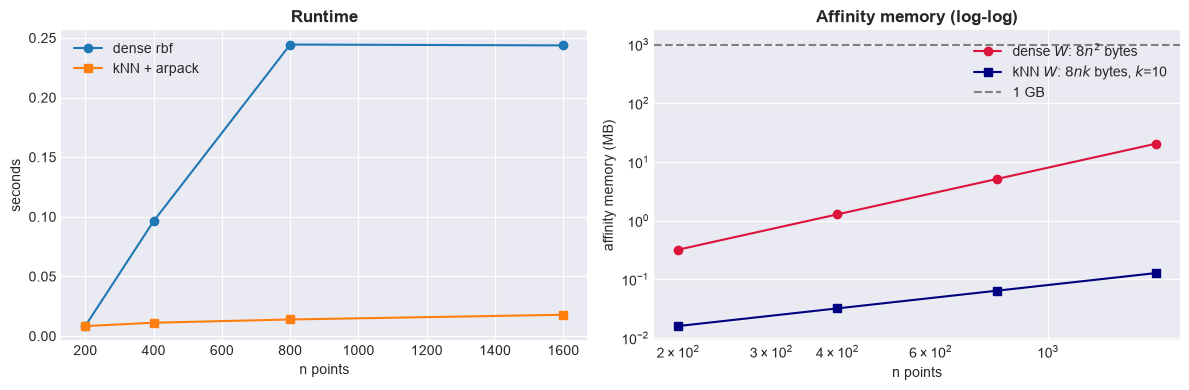

extrapolated dense affinity at n=10,000: 0.8 GB vs kNN(k=10) 0.8 MB
extrapolated dense affinity at n=100,000: 80.0 GB vs kNN(k=10) 8.0 MB

The memory column is the real wall — the dense affinity becomes impossible before the
eigendecomposition becomes merely slow. This is why nearest_neighbors is the practical default.


In [6]:
sizes = [200, 400, 800, 1600]
print(f"{'n':>6}{'dense W (MB)':>15}{'dense (s)':>12}{'kNN+arpack (s)':>17}{'speed-up':>11}")
print('-' * 61)
rec = []
for n in sizes:
    Xn, _ = make_moons(n_samples=n, noise=0.07, random_state=0)
    t0 = time.perf_counter()
    SpectralClustering(n_clusters=2, affinity='rbf', gamma=10, eigen_solver='arpack',
                       random_state=0).fit_predict(Xn)
    t_dense = time.perf_counter() - t0
    t0 = time.perf_counter()
    SpectralClustering(n_clusters=2, affinity='nearest_neighbors', n_neighbors=10,
                       eigen_solver='arpack', random_state=0).fit_predict(Xn)
    t_sparse = time.perf_counter() - t0
    mb = 8 * n * n / 1e6
    rec.append((n, mb, t_dense, t_sparse))
    print(f"{n:>6}{mb:>15.1f}{t_dense:>12.3f}{t_sparse:>17.3f}{t_dense / t_sparse:>10.1f}x")

ns = np.array([r[0] for r in rec], float)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ns, [r[2] for r in rec], 'o-', label='dense rbf')
axes[0].plot(ns, [r[3] for r in rec], 's-', label='kNN + arpack')
axes[0].set_xlabel('n points'); axes[0].set_ylabel('seconds')
axes[0].set_title('Runtime', fontweight='bold'); axes[0].legend()
axes[1].loglog(ns, 8 * ns ** 2 / 1e6, 'o-', color='crimson', label=r'dense $W$: $8n^2$ bytes')
axes[1].loglog(ns, 8 * ns * 10 / 1e6, 's-', color='navy', label=r'kNN $W$: $8nk$ bytes, $k$=10')
axes[1].axhline(1000, color='grey', ls='--', label='1 GB')
axes[1].set_xlabel('n points'); axes[1].set_ylabel('affinity memory (MB)')
axes[1].set_title('Affinity memory (log-log)', fontweight='bold'); axes[1].legend()
plt.tight_layout()
plt.show()

for n_big in [10_000, 100_000]:
    print(f"extrapolated dense affinity at n={n_big:,}: {8 * n_big ** 2 / 1e9:.1f} GB "
          f"vs kNN(k=10) {8 * n_big * 10 / 1e6:.1f} MB")
print("\nThe memory column is the real wall — the dense affinity becomes impossible before the")
print("eigendecomposition becomes merely slow. This is why nearest_neighbors is the practical default.")

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **The affinity is the model.** Sweeping `gamma` and `n_neighbors` on identical data moved ARI across nearly the whole range. Spectral clustering did not remove the tuning problem that K-Means has; it relocated it into the graph, where at least the parameter (a neighbourhood size) has a physical meaning.
2. **`nearest_neighbors` is the sensible default** — sparse, scale-adaptive, and the only affinity that stays viable as $n$ grows.
3. **The eigengap is far weaker on real data than on synthetic data.** In 17A it nailed K on separated blobs. Here the naive version returned K=1 on both wine and digits (the trivial $\lambda_2-\lambda_1$ gap), and even restricted to $k\ge2$ it gave 2 against wine's true 3. Spectral clustering still scored ARI 0.880 on wine *when told K=3* — so the algorithm was fine and the model selection was not. Do not let a tutorial convince you the eigengap solves K.
4. **Modularity and NCut are different questions.** Louvain scored *higher modularity than the true historical split* of the karate club. A better objective value is not a better answer unless the objective is your question.
5. **Density kills you before complexity does.** The dense affinity needs 800 MB at $n{=}10^4$ and 80 GB at $n{=}10^5$; the kNN graph needs 0.8 MB and 8 MB. The memory column, not the runtime column, is what forces the sparse path.

### Practical Guidance

- Start with `affinity='nearest_neighbors'`, `n_neighbors` around 10, `eigen_solver='arpack'`.
- Check connected components before trusting a result (17A showed the k < components failure).
- For images, concatenate position with colour and *weight* it deliberately; report a coherence measure rather than judging by eye.
- When the data is already a graph, use `affinity='precomputed'` and skip similarity construction entirely.
- Above roughly $10^4$ points, stop reaching for spectral clustering directly — subsample, use Nyström, or choose an algorithm with better scaling.

### What This Lesson Did Not Cover

- **Nyström approximation and landmark methods**, the standard route to large-$n$ spectral clustering. We measured the wall but did not climb it.
- **`assign_labels='discretize'` in depth** — it was included in the sweep, but the rotation-finding algorithm behind it was not derived.
- **Directed graphs and asymmetric affinities.** Everything here assumed $W = W^\top$.
- **Multi-scale / self-tuning affinities** (Zelnik-Manor & Perona), which set a per-point bandwidth from local density instead of one global $\sigma$ — the obvious fix for the sensitivity in Section 3, deliberately left out to keep the parameter story honest and visible.

### Next Steps

Lesson 18 turns from partitioning to **density**: kernel density estimation, where instead of asking which group a point belongs to we ask how probable that point is — the nonparametric counterpart to the GMM of Lesson 4 and the foundation for the flow and diffusion models in Lesson 19.